# Prepare dataset for size based classification



## Download fish dataset rejected due to size being one of the reasons

In [ ]:
! pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.7 MB/s eta 0:00:00


In [ ]:
import boto3
import os

os.environ['AWS_ACCESS_KEY_ID'] = ''
os.environ['AWS_SECRET_ACCESS_KEY'] = ''

In [ ]:
from urllib.parse import urlparse

def download_object_from_s3(url, destination_folder,
                            bucket_name='fish-data-collection-v2'):
    # Parse the URL to extract bucket name and object key
    parsed_url = urlparse(url)
    object_key = parsed_url.path[1:]  # Remove the leading '/'
    filename = os.path.join(destination_folder, os.path.basename(object_key))
    # print(f'Parsed URL: {parsed_url}\nBucket name: {bucket_name}\nObject key: {object_key}\n')

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    if os.path.exists(filename):
        return

    # Initialize a Boto3 S3 client
    s3 = boto3.client('s3')

    # Download the object
    try:
        response = s3.download_file(Bucket = bucket_name,
                                    Key = object_key,
                                    Filename = filename)
        # print('Object downloaded successfully.')
    except Exception as e:
        print('Error:', str(e))


In [ ]:
def classify_and_move_images2(df, destination_folder):
    for _, row in df.iterrows():
        image_url = row['image_url']
        image_type = row['type']
        image_label = row['labels']
        image_description = row['description']

        # Create destination directories if they don't exist
        type_folder = os.path.join(destination_folder, image_type)
        labels_folder = os.path.join(type_folder, image_label)
        description_folder = os.path.join(labels_folder, image_description)

        os.makedirs(description_folder, exist_ok=True)

        # Download the image from the provided URL
        download_object_from_s3(image_url, description_folder)

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Sowmya /reasons Dataset/testing_dataset.csv')
df.head()

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
0,3616,80310,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100835143_mackerel_bad.jpeg,2024-09-10
1,3624,80311,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100846100_mackerel_bad.jpeg,2024-09-10
2,5078,80312,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100901913_mackerel_bad.jpeg,2024-09-10
3,5139,80314,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910100955073_mackerel_bad.jpeg,2024-09-10
4,5221,80315,mackerel,bad,Softness,https://fish-data-collection-v2.s3.ap-south-1....,20240910101056814_mackerel_bad.jpeg,2024-09-10


In [ ]:
c1 = (df['type']=='sardine')
c2 = (df['labels']=='bad')
t = df.loc[(c1)&(c2)]
t = t[t['description'].str.contains('Size')]
t.head()

,Unnamed: 0,id,type,labels,description,image_url,Filename,Date
4649,31242,31271,sardine,bad,"Softness, Size",https://fish-data-collection.s3.ap-south-1.ama...,20231201092318649_sardine_bad.jpeg,2023-12-01
5087,32106,32265,sardine,bad,Size,https://fish-data-collection.s3.ap-south-1.ama...,20231205093846774_sardine_bad.jpeg,2023-12-05
5088,32107,32266,sardine,bad,Size,https://fish-data-collection.s3.ap-south-1.ama...,20231205093856709_sardine_bad.jpeg,2023-12-05
5709,34267,34386,sardine,bad,Size,https://fish-data-collection.s3.ap-south-1.ama...,20231217101935383_sardine_bad.jpeg,2023-12-17
5710,34268,34387,sardine,bad,Size,https://fish-data-collection.s3.ap-south-1.ama...,20231217101956087_sardine_bad.jpeg,2023-12-17


In [ ]:
destination_folder = '/content/drive/MyDrive/Sowmya /reasons Dataset'
classify_and_move_images2(t, destination_folder)

In [ ]:
df = pd.DataFrame(t['description'].unique(), columns=['description'])
folderpath = '/content/drive/MyDrive/Sowmya /reasons Dataset/sardine/bad'
df['folder_count'] = df['description'].apply(lambda x: len(os.listdir(os.path.join(folderpath, x))))
df['actual_count'] = df['description'].apply(lambda x: t[t['description']==x].shape[0])
display(df)
print("\n", (df['actual_count'].sum()==df['folder_count'].sum()))

,description,folder_count,actual_count
0,"Softness, Size",64,64
1,Size,325,325
2,"Size, Softness",65,65
3,"Softness, Cuts and Damage, Size",2,2
4,"Cuts and Damage, Size, Softness",3,3
5,"Size, Cuts and Damage",6,6
6,"Cuts and Damage, Softness, Size",2,2
7,"Softness, Size, Cuts and Damage",1,1
8,"Cuts and Damage, Size",3,3
9,"Size, Cuts and Damage, Softness",2,2



 True


## Combine all the data into a single folder

In [ ]:
import os
from tqdm import tqdm
import shutil

In [ ]:
folderpath = '/content/drive/MyDrive/Sowmya /models/experiments'
size_data = os.path.join(folderpath, 'size_data', 'Sardine', 'Bad')
os.makedirs(size_data, exist_ok=True)

In [ ]:
l = list(t['description'].unique())
src_folder = '/content/drive/MyDrive/Sowmya /reasons Dataset/sardine/bad'
for i in l:
    folder = os.path.join(src_folder, i)
    for file in tqdm(os.listdir(folder), desc=f'{i}'):
        src = os.path.join(folder, file)
        des = os.path.join(size_data, file)
        if os.path.exists(des): continue
        shutil.copy(src, des)

Size, Softness, Cuts and Damage: 100%|██████████| 1/1 [00:00<00:00, 1855.07it/s]


In [ ]:
df['folder_count'].sum(), len(os.listdir(size_data))

(474, 474)

In [ ]:
len(set(os.listdir(size_data))) # to find if there are any duplicates

474

## Function to create a DataFrame interactively


In [ ]:
import os
import cv2
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, clear_output

def create_dataframe_with_heights(image_folder, excel_filepath):
    '''
    Create a DataFrame with the heights of the images in the folder
    and save it to an Excel file.

    Args:
        image_folder (str): Path to the folder containing the images.
        excel_filepath (str): Path to the Excel file to save the DataFrame.

    Returns:
        pandas.DataFrame: The DataFrame containing image filenames and heights.
    '''
    # Check if Excel file exists, if not, initialize an empty DataFrame
    if os.path.exists(excel_filepath):
        df = pd.read_excel(excel_filepath)
    else:
        df = pd.DataFrame(columns=['filename', 'height'])


    # Loop through the images in the folder
    for filename in tqdm(sorted(os.listdir(image_folder))):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            # If the image already has an entry, skip it
            if filename in df['filename'].values:
                continue
            # Display the image
            clear_output(wait=True)  # Clear previous output to avoid clutter
            img_path = os.path.join(image_folder, filename)
            img = mpimg.imread(img_path)
            h, w = img.shape[:2]
            if h > w:
                # rotate image
                img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
            plt.figure(figsize=(15, 4))
            resized = cv2.resize(img, (1000, 300))
            plt.imshow(resized)
            plt.axis('off')  # Turn off axis for better view
            display(plt.gcf())  # Ensure the plot is rendered before moving on
            plt.show()

            while True:
                try:
                    # After displaying the image, ask the user to input the height
                    height = float(input(f"\nEnter the height of the image '{filename}': "))
                    break
                except:
                    # Validate that the input is a valid number
                    stop = input('\nInvalid input. Do you want to stop execution? ')
                    if stop.lower()=='yes':
                        return df
                    print("Please enter a valid number for height.")

            # Create a new DataFrame with the new data
            new_data = pd.DataFrame({'filename': [filename], 'height': [height]})

            # Concatenate the new data with the existing DataFrame
            df = pd.concat([df, new_data], ignore_index=True)

            # Save the updated DataFrame to Excel
            df.to_excel(excel_filepath, index=False)
            print(f"\nData for '{filename}' saved to {excel_filepath}")

    print("\n-----------All images processed!------------")
    return df

create a dataframe with the filename and fish height manually measured in cms

we can use this height as a reference height to convert other dimensions' pixels to centimeters

In [ ]:
size_data

NameError: name 'size_data' is not defined

In [ ]:
# Usage example:
# Provide the path to the folder containing your images
image_folder = '/content/path_to_your_images_folder'
image_folder = size_data
folderpath = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine'
excel_filepath = os.path.join(folderpath, 'bad_fish_height_data.xlsx')
df = create_dataframe_with_heights(image_folder, excel_filepath)

100%|██████████| 474/474 [00:00<00:00, 31503.14it/s]


-----------All images processed!------------


around 20240229 made some mistakes maybe around 5 images

## Download Good class data with scale

In [ ]:
import os
import pandas as pd

# Define the directory path
daily_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data'

# Initialize an empty DataFrame
df = pd.DataFrame()

# List to store data before creating the DataFrame
data = []

# Loop through each date folder
for date in os.listdir(daily_data):
    folder = os.path.join(daily_data, date, 'Sardine', 'Good', 'Single')

    # Check if the folder exists
    if os.path.exists(folder):
        # Get the list of files in the folder
        file_list = os.listdir(folder)

        # Append the data to the list
        data.append({
            'Date': date,
            'Count': len(os.listdir(folder)),
            'Filename': os.listdir(folder)[0]  # Join filenames into a string separated by commas
        })

# Create the DataFrame using the list of dictionaries
df = pd.concat([df, pd.DataFrame(data)], ignore_index=True)

df

,Date,Count,Filename
0,2023-05-23,16,20230523094534352_sardine_good.jpeg
1,2023-05-26,44,20230526111930564_sardine_good.JPEG
2,2023-05-27,41,20230527075226190_sardine_good.JPEG
3,2023-05-28,37,20230528091620240_sardine_good.JPEG
4,2023-05-30,16,20230530094049961_sardine_good.JPEG
...,...,...,...
121,2024-08-01,12,20240801105650600_sardine_good.jpeg
122,2024-08-03,51,20240803092846703_sardine_good.jpeg
123,2024-08-13,15,20240813113527535_sardine_good.jpeg
124,2024-08-20,16,20240820125852060_sardine_good.jpeg


In [ ]:
df.loc[70:]

,Date,Count,Filename
70,2023-12-28,153,20231228090320169_sardine_good.jpeg
71,2023-12-29,61,20231229114130972_sardine_good.jpeg
72,2023-12-30,20,20231230092255446_sardine_good.jpeg
73,2024-01-02,42,20240102085545675_sardine_good.jpeg
74,2024-01-04,44,20240104102629762_sardine_good.jpeg
75,2024-01-06,40,20240106120044182_sardine_good.jpeg
76,2024-01-09,37,20240109120234935_sardine_good.jpeg
77,2024-01-11,44,20240111122035271_sardine_good.jpeg
78,2024-01-13,9,20240113120910680_sardine_good.jpeg
79,2024-01-18,56,20240118103819159_sardine_good.jpeg


In [ ]:
import matplotlib.pyplot as plt
import cv2

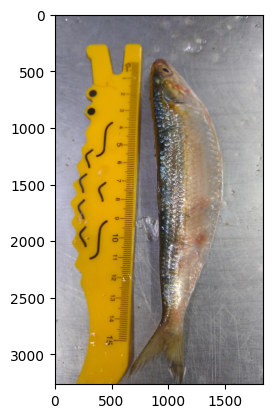

In [ ]:
date = '2024-07-27'
filename = '20240727123724617_sardine_good.jpeg'
filepath = os.path.join(daily_data, date, 'Sardine', 'Good', 'Single', filename)
img = cv2.imread(filepath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

2024-02-13, 2024-02-15, 2024-02-22, 2024-02-24, 2024-02-29, 2024-03-02, 2024-03-13, 2024-03-19, 2024-03-20(half), 2024-03-21, 2024-03-23, 2024-04-11(half), 2024-04-17, 2024-04-23, 2024-05-16, 2024-07-25

05-21, 05-23, 05-28, 05-30, 06-04, 06-20, 07-09, 07-16, 07-23, 07-27

data with scale is being taken since 2024 February 13 for sardine good

In [ ]:
import os
import shutil
from tqdm import tqdm

dates_list = ['2024-02-13', '2024-02-15', '2024-02-22', '2024-02-24', '2024-02-29',
              '2024-03-02', '2024-03-13', '2024-03-19', '2024-03-21', '2024-03-23',
              '2024-04-17', '2024-04-23', '2024-05-16', '2024-07-25']
image_folder = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/Good'
daily_data = '/content/drive/MyDrive/Sowmya /qZense Dataset/S3 Data/Daily Data'
# dates_list = ['2024-02-13']
for date in dates_list:
    folder = os.path.join(daily_data, date, 'Sardine', 'Good', 'Single')
    if os.path.exists(folder):
        # copy all the images to image_folder
        for filename in tqdm(os.listdir(folder), desc=f'{date}'):
            src = os.path.join(folder, filename)
            des = os.path.join(image_folder, filename)
            if os.path.exists(des): continue
            shutil.copy(src, des)

2024-07-25: 100%|██████████| 1/1 [00:00<00:00, 20.11it/s]


In [1]:
import os
import cv2
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, clear_output

def create_dataframe_with_heights2(image_folder, excel_filepath):
    '''
    Create a DataFrame with the heights of the images in the folder
    and save it to an Excel file. Handles user corrections and navigation.

    Args:
        image_folder (str): Path to the folder containing the images.
        excel_filepath (str): Path to the Excel file to save the DataFrame.

    Returns:
        pandas.DataFrame: The DataFrame containing image filenames and heights.
    '''

    # Check if Excel file exists, if not, initialize an empty DataFrame
    if os.path.exists(excel_filepath):
        df = pd.read_excel(excel_filepath)
    else:
        df = pd.DataFrame(columns=['filename', 'height'])

    back = False
    image_index = 0
    # Loop through the images using a while loop with tqdm
    with tqdm(total=len(sorted(os.listdir(image_folder)))) as pbar:
        while image_index < len(sorted(os.listdir(image_folder))):
            filename = sorted(os.listdir(image_folder))[image_index]
            if filename.endswith(('.png', '.jpg', '.jpeg')):

                # Skip processed images (unless going back)
                if filename in df['filename'].values and not back:
                    image_index += 1
                    pbar.update(1)
                    continue

                # Display the image
                clear_output(wait=True)
                img_path = os.path.join(image_folder, filename)
                img = mpimg.imread(img_path)
                h, w = img.shape[:2]
                if h > w:
                    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
                # plt.close('all')  # Close any previous plot
                plt.figure(figsize=(15, 4))
                resized = cv2.resize(img, (1000, 300))
                plt.imshow(resized)
                plt.axis('off')
                display(plt.gcf())
                plt.show()

                while True:
                    print('\n*******************',image_index,'*******************')
                    try:
                        # User input with option to go back
                        user_input = input(f"\nEnter the height of the image '{filename}' (or 'back' to correct): ").lower()

                        if user_input == 'back':
                            # Handle going back: decrement index, validate
                            if image_index > 0:
                                image_index -= 1
                                back = True
                                display(df)
                                filename = df.iloc[-1]['filename']
                                print(f"\nGoing back to image: {filename}")
                                image_index -= 1
                            else:
                                print("\nCannot go back further. Please enter a height or 'quit'.")
                            break

                        else:
                            height = float(user_input)  # Validate numeric input
                            break

                    except ValueError:
                        stop = input('\nInvalid input. Do you want to stop execution? (yes/no) ')
                        if stop.lower() == 'yes':
                            return df
                        print("Please enter a valid number for height.")

                # Update DataFrame and progress bar
                if user_input.lower() != 'back':
                    new_data = pd.DataFrame({'filename': [filename], 'height': [height]})
                    df = pd.concat([df, new_data], ignore_index=True)
                    df.to_excel(excel_filepath, index=False)
                    print(f"\nData for '{filename}' saved to excel_filepath")
                    pbar.update(1)  # Update progress bar

            image_index += 1

    print("\n-----------All images processed!------------")
    return df

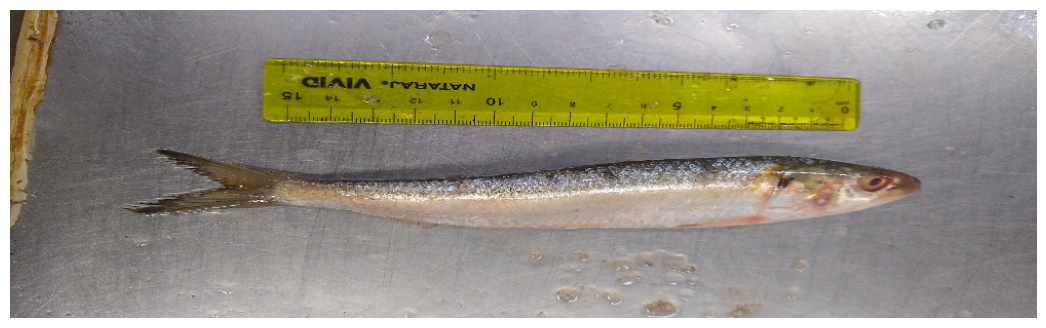

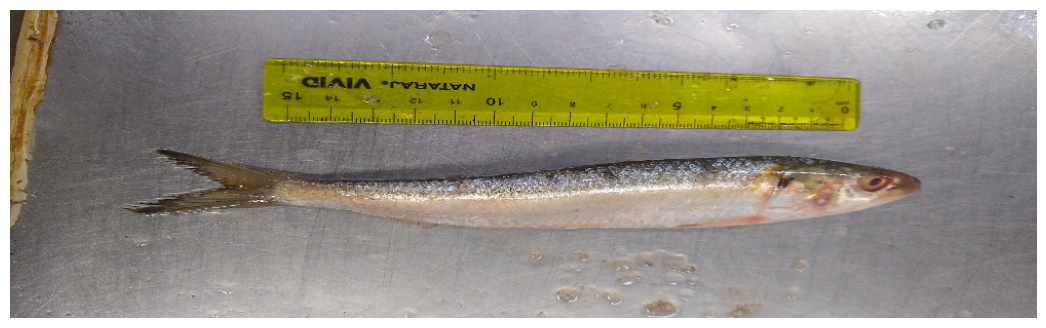


******************* 471 *******************

Enter the height of the image '20240313112403332_sardine_good.jpeg' (or 'back' to correct): e

Invalid input. Do you want to stop execution? (yes/no) yes


 63%|██████▎   | 471/753 [49:38<29:43,  6.32s/it]  


In [2]:
image_folder = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine/Good'
folderpath = '/content/drive/MyDrive/Sowmya /models/experiments/size_data/Sardine'
excel_filepath = os.path.join(folderpath,'good_fish_height_data.xlsx')
df = create_dataframe_with_heights2(image_folder, excel_filepath)

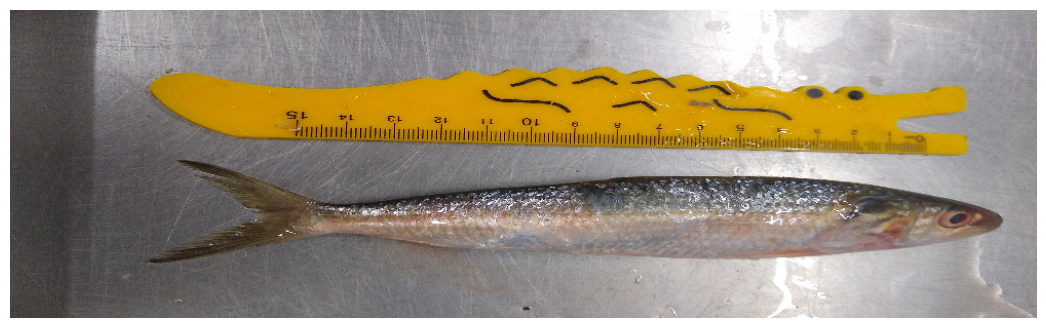

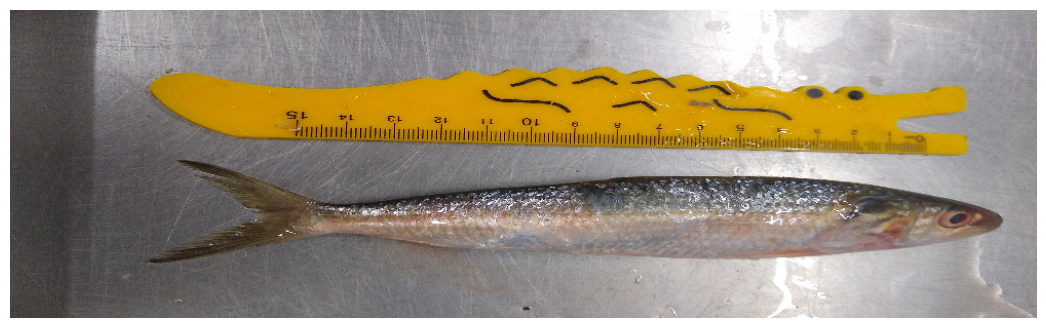

In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_image(image_folder, filename):
    # Display the image
    img_path = os.path.join(image_folder, filename)
    img = mpimg.imread(img_path)
    h, w = img.shape[:2]
    if h > w:
        img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    plt.close()
    plt.figure(figsize=(15, 4))
    resized = cv2.resize(img, (1000, 300))
    plt.imshow(resized)
    plt.axis('off')
    display(plt.gcf())
    plt.show()


display_image(image_folder, '20240222085804054_sardine_good.jpeg')